In [ ]:
# import json
# from tabulate import tabulate
# from rank_bm25 import BM25Okapi

# import wandb
# from datasets import Dataset
# from sentence_transformers import CrossEncoder
# from sentence_transformers.cross_encoder.trainer import CrossEncoderTrainer
# from sentence_transformers.cross_encoder.training_args import CrossEncoderTrainingArguments
# from sentence_transformers.cross_encoder.losses import BinaryCrossEntropyLoss
# from sentence_transformers.cross_encoder.evaluation import CrossEncoderRerankingEvaluator

# import matplotlib.pyplot as plt

### Preprocessing

In [ ]:

def load_json(filename: str):
    with open(f'./{filename}.json', 'r') as file:
        data = json.load(file)
    return data

dev_json = load_json('dev')
test_json = load_json('test')
train_json = load_json('train')

In [ ]:
def display_example(example: dict):
    return "\n".join([
        "\n".join(example['pre_text']),
        str(tabulate(example['table'], headers="firstrow", tablefmt="simple")),
        "\n".join([ text for text in list(example['post_text']) if text != "." ]),
    ])

def format_table(example: dict) -> dict:
    table = list(example['table'])
    if len(table) == 0: return { }
    table_dict = { }
    header = table[0]
    for n, row in enumerate(table[1:]):
        formatted_row = [ header[0] ] if header[0] != '' else [ ]
        for idx in range(len(header) - 1):
            pos = idx + 1
            formatted_row.append(f"the {row[0]} of {header[pos]} is {row[pos]} ;")    # FinQA format
        rowstring = " ".join(formatted_row)
        table_dict[f"table_{n + 1}"] = rowstring
    return table_dict

def format_text(example: dict) -> dict:
    pre_text_list = list(example['pre_text'])
    pos_text_list = list(example['post_text'])
    pre_text_list.extend(pos_text_list)
    text_dict = { }
    for idx, entry in enumerate(pre_text_list):
        if (entry == "."): continue
        text_dict[f"text_{idx}"] = entry
    return text_dict

In [ ]:
fail_count, pass_count = 0, 0
for example in train_json:
    text_dict = format_text(example)
    table_dict = format_table(example)
    for key, value in example['qa']['gold_inds'].items():
        located = text_dict.get(key, table_dict.get(key, 'this information is not provided.'))
        if value == located:
            pass_count += 1
            continue
        fail_count += 1

# from a visual inspection, most of these are close-misses (spaces / formatting differences)
print(fail_count / (pass_count + fail_count))

0.05910961466517022


In [ ]:
def has(li, s) -> bool:
    for el in li:
        if s in el: return True
    return False

def retrieval_dataset(raw_data: list[dict]):
    # return ( text_dict | table_dict, question, gold_inds, text_needed, table_needed )
    dataset = [ ]
    for example in raw_data:
        inds = list(example['qa']['gold_inds'].keys())
        dataset.append( ( format_text(example) | format_table(example), example['qa']['question'], inds, has(inds, 'text'), has(inds, 'table')) )
    return dataset

In [ ]:
train_data = retrieval_dataset(train_json)
test_data = retrieval_dataset(test_json)
dev_data = retrieval_dataset(dev_json)

In [ ]:
dev_data[0]

({'text_0': 'largest operators of open-loop and closed-loop retail electronic payments networks the largest operators of open-loop and closed-loop retail electronic payments networks are visa , mastercard , american express , discover , jcb and diners club .',
  'text_1': 'with the exception of discover , which primarily operates in the united states , all of the other network operators can be considered multi- national or global providers of payments network services .',
  'text_2': 'based on payments volume , total volume , number of transactions and number of cards in circulation , visa is the largest retail electronic payments network in the world .',
  'text_3': 'the following chart compares our network with those of our major competitors for calendar year 2007 : company payments volume volume transactions cards ( billions ) ( billions ) ( billions ) ( millions ) visa inc. ( 1 ) .',
  'text_43': '$ 2457 $ 3822 50.3 1592 .',
  'text_44': '( 1 ) visa inc .',
  'text_45': 'figures as

### Metrics (accuracy + latency)

Standard code for computing @k metrics with varying values of k. As a precision/recall frontier for multiple k values.

In [ ]:
import math

def recall_at_k(pred_ids, gold_ids, k):
    pred = set(pred_ids[:k])
    gold = set(gold_ids)
    return 0.0 if not gold else len(pred & gold) / len(gold)

def precision_at_k(pred_ids, gold_ids, k):
    pred = set(pred_ids[:k])
    gold = set(gold_ids)
    return 0.0 if k == 0 else len(pred & gold) / min(k, len(pred_ids[:k]))

def f1_at_k(pred_ids, gold_ids, k):
    p = precision_at_k(pred_ids, gold_ids, k)
    r = recall_at_k(pred_ids, gold_ids, k)
    return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)

def mrr(pred_ids, gold_ids):
    gold = set(gold_ids)
    for i, pid in enumerate(pred_ids, start=1):
        if pid in gold:
            return 1.0 / i
    return 0.0

def ndcg_at_k(pred_ids, gold_ids, k):
    gold = set(gold_ids)
    def dcg(ids):
        s = 0.0
        for i, pid in enumerate(ids[:k], start=1):
            rel = 1.0 if pid in gold else 0.0
            s += (2**rel - 1) / math.log2(i + 1)
        return s
    ideal = list(gold)[:k]
    denom = dcg(ideal)
    return 0.0 if denom == 0 else dcg(pred_ids) / denom

import matplotlib.pyplot as plt
import time, math
import numpy as np

def evaluate(run_fn, dataset, ks=list(range(1, 20, 1)), ndcg_k=10, warmup=3):
    agg = {f"{m}@{k}":0.0 for m in ("R","P","F1") for k in ks} | {"MRR":0.0, f"nDCG@{ndcg_k}":0.0}
    lat = []
    for i, ex in enumerate(dataset):
        t0 = time.perf_counter()
        pred = run_fn(ex)
        dt = (time.perf_counter() - t0) * 1000.0
        if i >= warmup: lat.append(dt)
        gold = ex[2]
        for k in ks:
            agg[f"R@{k}"]  += recall_at_k(pred, gold, k)
            agg[f"P@{k}"]  += precision_at_k(pred, gold, k)
            agg[f"F1@{k}"] += f1_at_k(pred, gold, k)
        agg["MRR"] += mrr(pred, gold)
        agg[f"nDCG@{ndcg_k}"] += ndcg_at_k(pred, gold, ndcg_k)
    n = max(1, len(dataset))
    out = {k: v / n for k, v in agg.items()}
    if lat:
        lat = np.array(lat, dtype=float)
        out |= { "lat_ms_mean": float(lat.mean()),
            "lat_ms_p50":  float(np.percentile(lat, 50)),
            "lat_ms_p95":  float(np.percentile(lat, 95)) }
    return out

def plot_eval(outs, ks=list(range(1, 20, 1)), ndcg_k=10, title_prefix=""):
    ks = list(sorted(ks))
    outs = outs if isinstance(outs, dict) else {"model": outs}

    plt.figure()
    for label, out in outs.items():
        R = [out[f"R@{k}"] for k in ks]
        P = [out[f"P@{k}"] for k in ks]
        plt.plot(R, P, marker="o", label=label)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix}PR@K frontier".strip())
    plt.xlim(0,1); plt.ylim(0,1)
    plt.grid(True)
    plt.legend()
    plt.show()

    for metric in ("R", "P", "F1"):
        plt.figure()
        for label, out in outs.items():
            vals = [out[f"{metric}@{k}"] for k in ks]
            plt.plot(ks, vals, marker="o", label=label)
        plt.xlabel("K")
        plt.ylabel(metric)
        plt.title(f"{title_prefix}{metric}@K vs K".strip())
        plt.ylim(0,1)
        plt.grid(True)
        plt.legend()
        plt.show()

    key = f"nDCG@{ndcg_k}"
    for label, out in outs.items():
        if key in out:
            print(f"{title_prefix}{label} {key}: {out[key]:.4f}")

    lat_keys = ["lat_ms_mean", "lat_ms_p50", "lat_ms_p95"]
    for label, out in outs.items():
        if any(k in out for k in lat_keys):
            print(label, {k: out[k] for k in lat_keys if k in out})

def evaluate_and_plot(run_fn, dataset, ks, name):
    plot_eval({ name: evaluate(run_fn, dataset, ks) }, ks)

### BM25 search (zero-shot) – baseline

In [ ]:
def tokenize(s):    # remove stop words / punctuation (?)
    return s.lower().split()

def bm25_run(question: str, input_dict: dict, top_k: int = 5):
    input_items = list(input_dict.items())  # reference ordering
    bm25_index = BM25Okapi( [ tokenize(item[1]) for item in input_items ] )
    scores = bm25_index.get_scores(tokenize(question))
    ranked = sorted(list(range(len(input_items))), key=lambda i: scores[i], reverse=True)[:top_k]
    results = { input_items[index][0]: scores[index] for index in ranked }
    return [ input_items[index][0] for index in ranked ]

def call_bm25_run(example):
    input_dict, question, gold_inds, _, _ = example
    return bm25_run(question, input_dict, top_k=20)

Higher k means higher recall but lower precision. Choosing different values of k can give us a precision-recall frontier over various reasonable choices of k (from 1-20). For use in a downstream agent, we'd probably prioritize recall over precision since the agent can filter / reason over provided chunks.

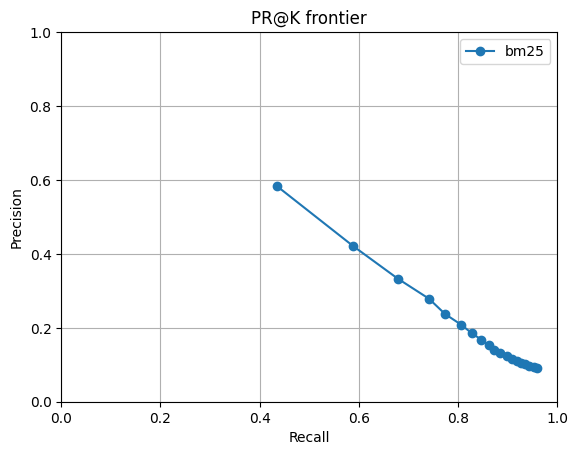

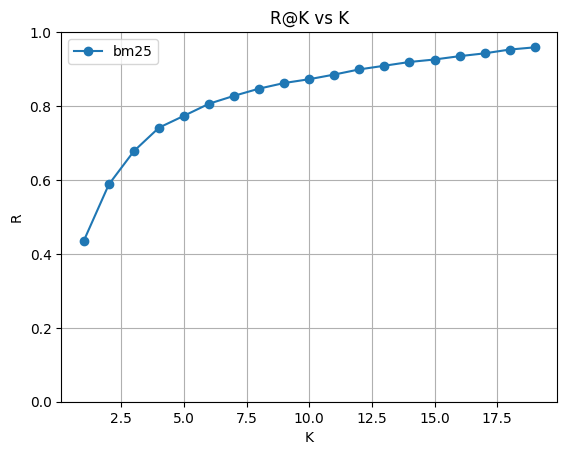

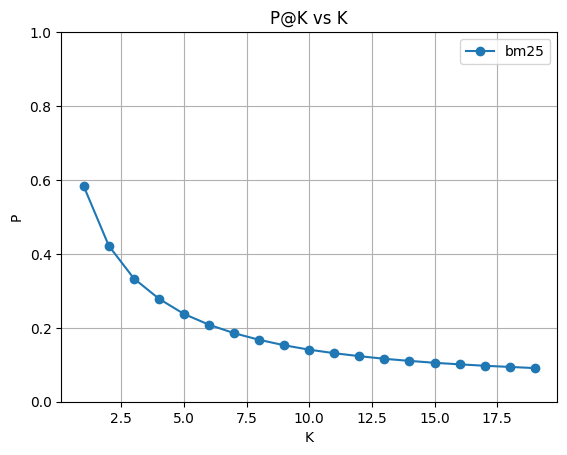

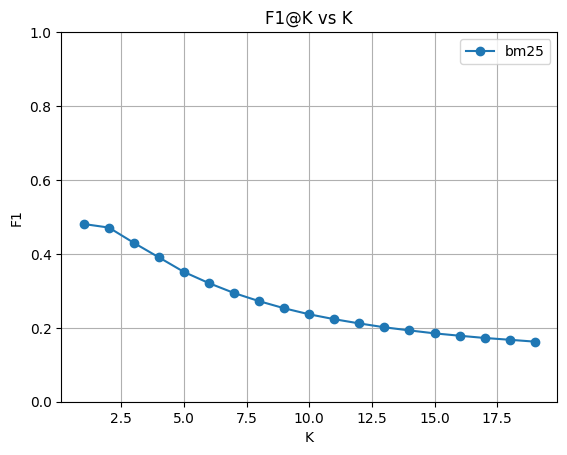

bm25 nDCG@10: 0.7182
bm25 {'lat_ms_mean': 0.7584140200960846, 'lat_ms_p50': 0.7297815009223996, 'lat_ms_p95': 1.1665004496535403}


In [ ]:
bm25_results = evaluate(call_bm25_run, dataset=test_data)
plot_eval({ "bm25": bm25_results })

There's a lot of room for improvement. One immediate idea is to see if removing text/table helps (when the data isn't necessarily from there). For this, it would make sense to train a cheap classifier to predict if a relevant sentence is included in the corpus or not. Before training the classifier, let's assume that the classifier is perfect. If this is useful, we'll continue on.

### Ablation: text/table/both classifier

In [ ]:
# we'll call this sectionwise
def call_bm25_sectionwise(example):
    input_dict, question, gold_inds, text_needed, table_needed = example
    def include(index):
        return (('text' in index) and text_needed) or (('table' in index) and table_needed)
    raw_results = bm25_run(question, input_dict, top_k=100)
    results = [ i for i in raw_results if include(i) ][:20]
    if len(results) == 0:   # safety check
        return raw_results[:20]
    return results

This is a pretty big step-function jump in all metrics. So there clearly is some value in training a classifier if we get this right.

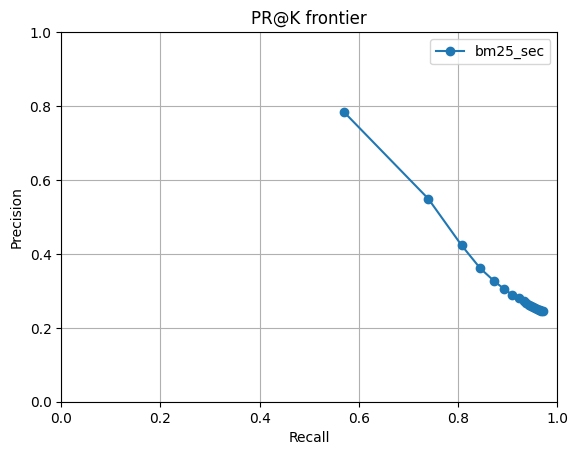

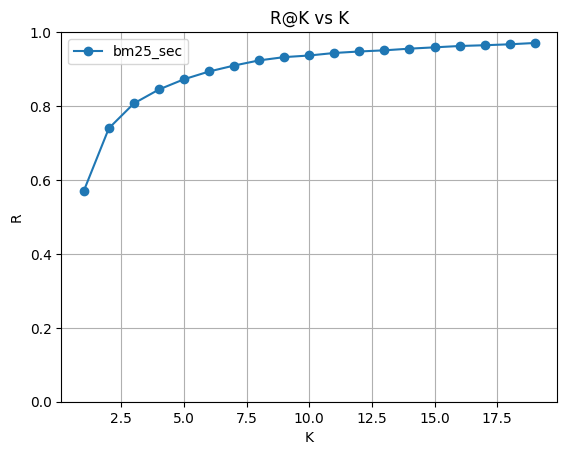

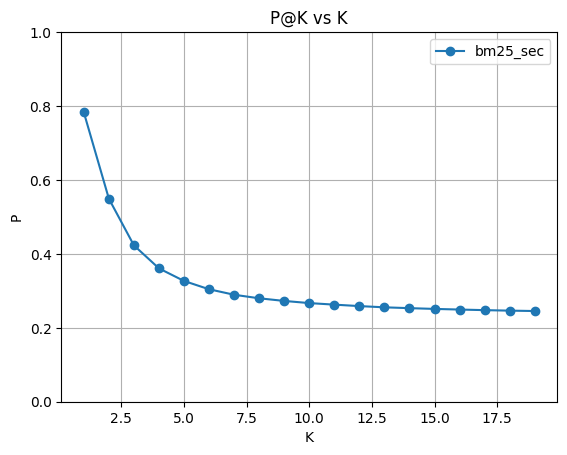

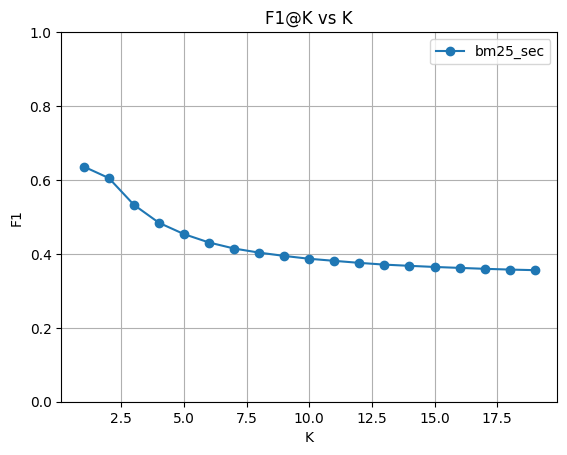

bm25_sec nDCG@10: 0.8438
bm25_sec {'lat_ms_mean': 0.7251115603028322, 'lat_ms_p50': 0.7192655002654647, 'lat_ms_p95': 1.044299799195869}


In [ ]:
bm25_sectionwise_results = evaluate(call_bm25_sectionwise, dataset=test_data)
plot_eval({ "bm25_sec": bm25_sectionwise_results })

### Dense, embedding search (0-shot) – not a sensible solution

Dense embeddings are actually really slow here: this is because the set of candidates is 20-50 per question. There are only a few overlaps. If the corpus remained the same, it would make a lot of sense to use dense search. But since we have so few candidates, we can re-rank directly.

### Reranker (pre-trained)

From a visual inspection of the results, it seems that our precision is low (but recall seems to be ok). Reranking also makes much more sense given the number of candidates. This can be used in-conjunction with the BM25 scores (we can do some kind of Boosting or weighted sum).

In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"     # explicitly pretrained for IR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)

In [ ]:
@torch.no_grad()
def rerank_run(question, input_dict, top_k=20, bs=32):
    items = list(input_dict.items())
    ids   = [cid for cid,_ in items]
    texts = [t   for _,t in items]
    model.eval()
    scores = []
    for i in range(0, len(texts), bs):
        bt = texts[i:i+bs]
        enc = tok([question]*len(bt), bt, padding=True, truncation=True, return_tensors="pt").to(device)
        logits = model(**enc).logits
        p = (torch.sigmoid(logits.squeeze(-1)) if logits.size(-1) == 1 else torch.softmax(logits, -1)[:, 1])
        scores.extend(p.detach().cpu().tolist())
    idx = np.argsort(-np.array(scores))[:top_k]
    return [ids[i] for i in idx]

def call_rerank_run(example):
    input_dict, question, *_ = example
    return rerank_run(question, input_dict, top_k=20)

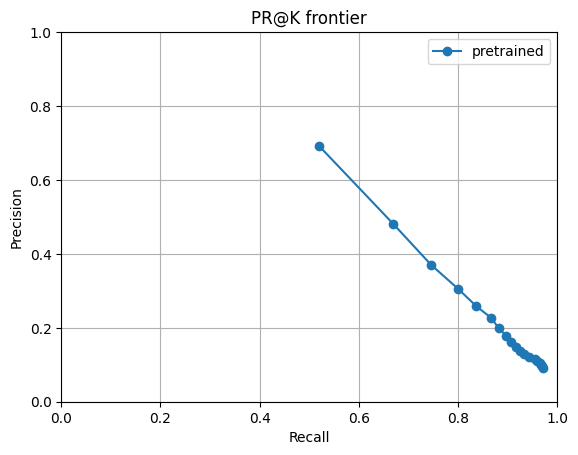

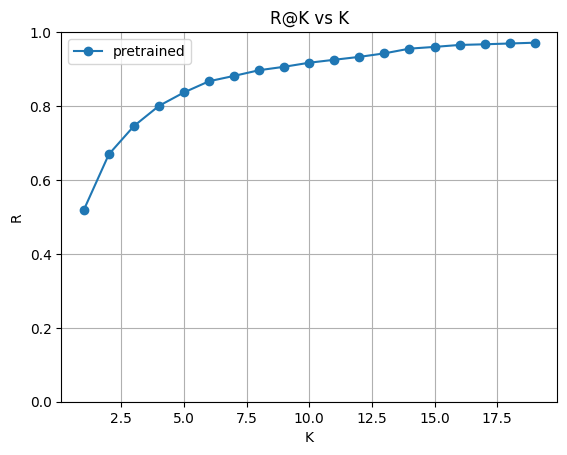

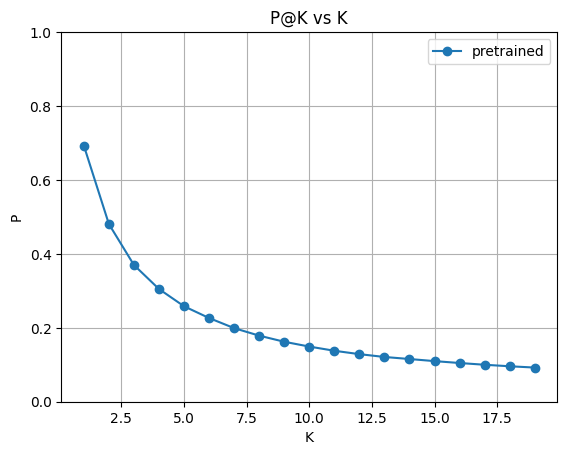

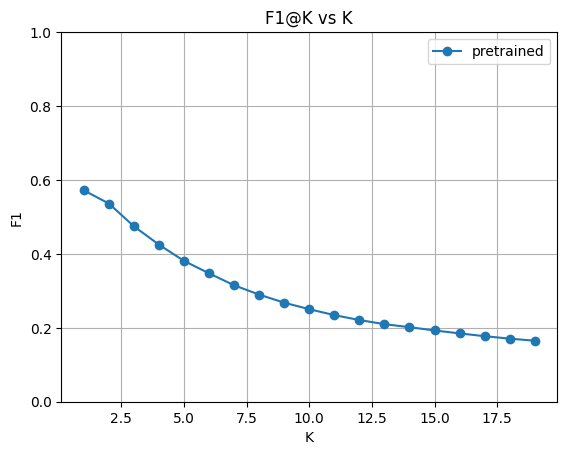

pretrained nDCG@10: 0.7929
pretrained {'lat_ms_mean': 14.916633403831806, 'lat_ms_p50': 13.30597150081303, 'lat_ms_p95': 24.782243651225137}


In [ ]:
results_pretrained = evaluate(call_rerank_run, dataset=test_data)
plot_eval({ "pretrained": results_pretrained })

This is already a nice improvement over BM25 out of the box. Now, let's fine-tune our reranker. The idea is to use the gold inds to teach the model what sentences matter and what do not. Then, we can use `logprobs` to rerank the input. Hopefully this produces an improvement.

### Reranker (fine-tuned)

Since we have (query, doc, label) pairs (triples?), it makes sense to use a standard BCE loss (Binary Cross Entropy). The first task is to reshape the training and validation data into (query, pos_docs, neg_docs). We may also include the source section (text/table) into the document.

In [ ]:
def reranker_reshape(dataset, include=False):
    reshaped = [ ]
    for example in dataset:
        documents, query, gold_inds, _, _ = example
        pos_docs = [ (f"({key.split('_')[0]}): {doc}" if include else doc) for key, doc in documents.items() if key in gold_inds ]
        neg_docs = [ (f"({key.split('_')[0]}): {doc}" if include else doc) for key, doc in documents.items() if key not in gold_inds ]
        reshaped.append( { "query": query, "pos": pos_docs, "neg": neg_docs } )
    return reshaped

In [ ]:
train_rerank_incl = reranker_reshape(train_data, True)
dev_rerank_incl = reranker_reshape(dev_data, True)
test_rerank_incl = reranker_reshape(test_data, True)

train_rerank = reranker_reshape(train_data)
dev_rerank = reranker_reshape(dev_data)
test_rerank = reranker_reshape(test_data)

In [ ]:
# from datasets import Dataset
# from transformers import EarlyStoppingCallback

# train_data = train_rerank
# val_data = dev_rerank

# def prepare_training_data(data):
#     samples = []
#     for item in data:
#         for pos_doc in item["pos"]:
#             samples.append({"query": item["query"], "passage": pos_doc, "label": 1.0})
#         for neg_doc in item["neg"]:
#             samples.append({"query": item["query"], "passage": neg_doc, "label": 0.0})
#     return Dataset.from_list(samples)

# train_dataset = prepare_training_data(train_data)
# val_dataset = prepare_training_data(val_data)

# def prepare_eval_data(data):
#     return [{"query": item["query"], "positive": item["pos"], "negative": item["neg"]} for item in data]

# eval_samples = prepare_eval_data(val_data)

# SWEEP_CONFIGS = [
#     {
#         "name": "sweep-learning-rate",
#         "method": "grid",
#         "parameters": {
#             "learning_rate": {"values": [1e-4]},
#             "batch_size": {"value": 64},
#             "warmup_ratio": {"value": 0.1},
#         },
#     },
# ]

# def train():
#     run = wandb.init()
#     config = wandb.config

#     model = CrossEncoder(
#         model_name_or_path="cross-encoder/ms-marco-MiniLM-L-6-v2",
#         max_length=512,
#     )

#     evaluator = CrossEncoderRerankingEvaluator(
#         samples=eval_samples,
#         name="reranker",
#     )

#     training_args = CrossEncoderTrainingArguments(
#         output_dir=f"./reranker-sweep/{run.id}",
#         num_train_epochs=1,
#         per_device_train_batch_size=config.batch_size,
#         per_device_eval_batch_size=config.batch_size,
#         learning_rate=config.learning_rate,
#         warmup_ratio=config.warmup_ratio,
#         weight_decay=0.01,
#         fp16=True,
#         eval_strategy="steps",
#         eval_steps=200,
#         save_strategy="steps",
#         save_steps=200,
#         save_total_limit=1,
#         load_best_model_at_end=True,
#         metric_for_best_model="eval_loss",
#         logging_steps=10,
#         report_to="wandb",
#     )

#     loss = BinaryCrossEntropyLoss(model=model)

#     trainer = CrossEncoderTrainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=val_dataset,
#         loss=loss,
#         evaluator=evaluator,
#         callbacks=[EarlyStoppingCallback(early_stopping_patience=8, early_stopping_threshold=0.00005)],
#     )

#     trainer.train()
#     wandb.finish()


# PROJECT_NAME = "retriever-hpml"

# for sweep_config in SWEEP_CONFIGS:
#     print(f"\n{'='*60}")
#     print(f"Starting sweep: {sweep_config['name']}")
#     print(f"{'='*60}\n")

#     sweep_id = wandb.sweep(sweep_config, project=PROJECT_NAME)
#     wandb.agent(sweep_id, function=train, count=3)

# print("\nAll sweeps complete! Check wandb dashboard for results.")


Starting sweep: sweep-learning-rate

Create sweep with ID: 5uc3f85l
Sweep URL: https://wandb.ai/svk2118-columbia-university/retriever-hpml/sweeps/5uc3f85l


wandb: Agent Starting Run: y5t635ks with config:
wandb: 	batch_size: 64
wandb: 	learning_rate: 0.0001
wandb: 	warmup_ratio: 0.1


wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'warmup_ratio' was locked by 'sweep' (ignored update).


Step,Training Loss,Validation Loss,Reranker Map,Reranker Mrr@10,Reranker Ndcg@10
200,0.090800,0.116267,0.864525,0.919979,0.905217
400,0.083000,0.113974,0.859430,0.908212,0.898969
600,0.093600,0.121003,0.871939,0.922945,0.909931
800,0.083000,0.102128,0.866248,0.916650,0.904035
1000,0.102000,0.099301,0.874924,0.922717,0.912058
1200,0.131200,0.093683,0.890626,0.938395,0.923304
1400,0.079300,0.097011,0.892030,0.940617,0.925477
1600,0.100700,0.094918,0.890049,0.935054,0.922709
1800,0.088500,0.091286,0.889591,0.934451,0.922348
2000,0.109100,0.091485,0.890496,0.936274,0.923174


eval/loss,▇▇█▄▄▂▃▃▂▂▂▁▁
eval/reranker_map,▂▁▄▂▄▇█▇▇▇█▇█
eval/reranker_mrr@10,▄▁▄▃▄██▇▇▇█▇▇
eval/reranker_ndcg@10,▃▁▄▂▄▇█▇▇▇█▇█
eval/runtime,▂▃█▂▂▃▃▁▂▂▃▅▃
eval/samples_per_second,▇▆▁▇▇▆▆█▇▇▆▄▆
eval/steps_per_second,▇▆▁▇▇▆▆█▇▇▆▄▆
train/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█
train/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
train/grad_norm,▇▇▂▃▅▂▄█▃▃▄▃▇▄▃▁▃▃▆▂▄▅▃▆▄▄▆▅▃▅▄▁▁▅▄▂▃▃▃▂
+2,...


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.



All sweeps complete! Check wandb dashboard for results.


The best choice for learning rate and batch size are: 1e-4 and 64 respectively.

In [ ]:
BEST_RUN = 'b42q86ij'

def trained_rerank(model, query: str, documents: dict[str, str], top_k: int = 20) -> list[str]:
    keys = list(documents.keys())
    pairs = [[query, documents[k]] for k in keys]
    scores = model.predict(pairs)
    ranked = sorted(zip(keys, scores), key=lambda x: x[1], reverse=True)
    return [k for k, _ in ranked[:top_k]]

from sentence_transformers import CrossEncoder
trained_reranker_model = CrossEncoder(f"./reranker-sweep/{BEST_RUN}/checkpoint-2600")

def call_trained_rerank(example):
    input_dict, question, *_ = example
    return trained_rerank(trained_reranker_model, question, input_dict, top_k=20)

def call_rerank_sectionwise(example):
    input_dict, question, gold_inds, text_needed, table_needed = example
    def include(index):
        return (('text' in index) and text_needed) or (('table' in index) and table_needed)
    raw_results = trained_rerank(trained_reranker_model, question, input_dict, top_k=100)
    results = [ i for i in raw_results if include(i) ][:20]
    if len(results) == 0:   # safety check
        return raw_results[:20]
    return results

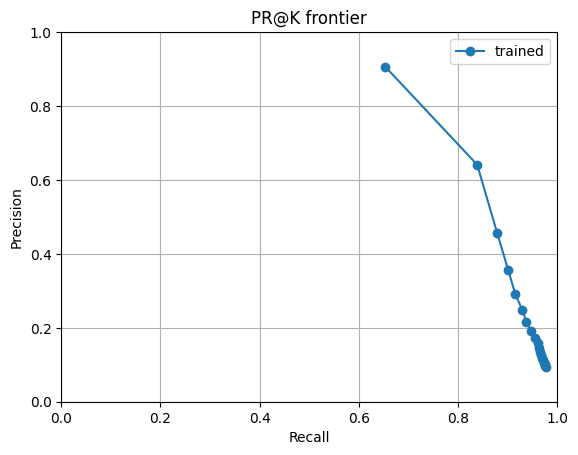

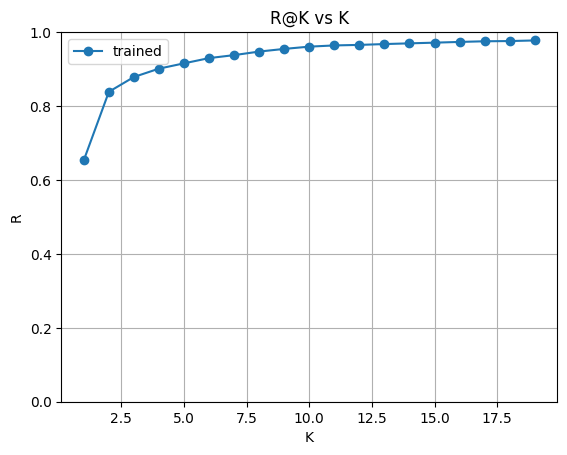

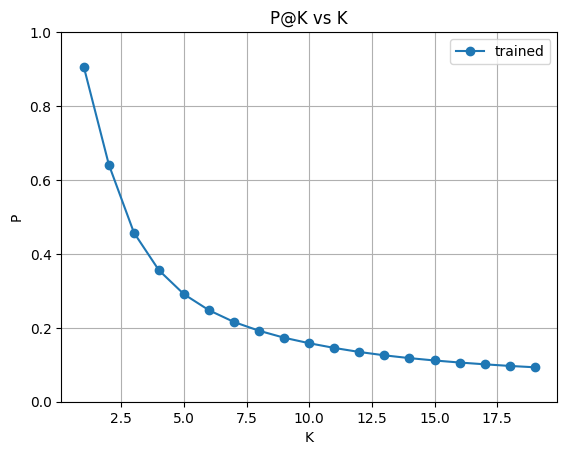

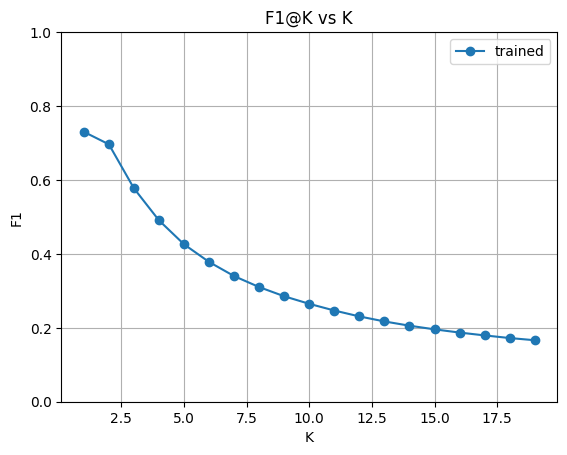

trained nDCG@10: 0.9148
trained {'lat_ms_mean': 14.156886531490292, 'lat_ms_p50': 12.923299999783922, 'lat_ms_p95': 21.945291749852906}


In [ ]:
results_ft = evaluate(call_trained_rerank, dataset=test_data)
plot_eval({ "trained": results_ft })

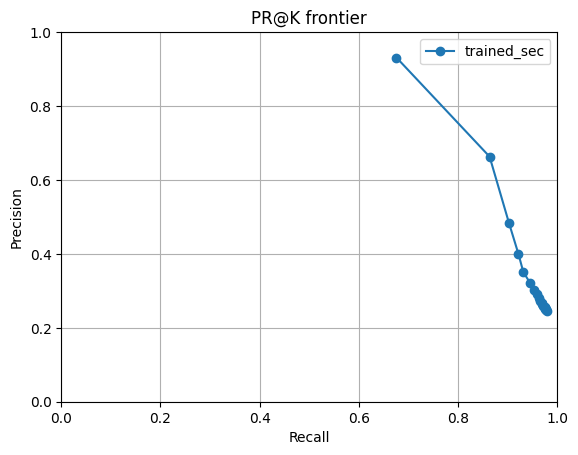

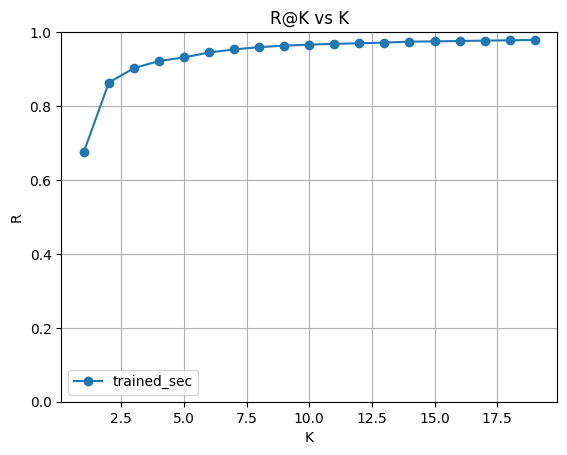

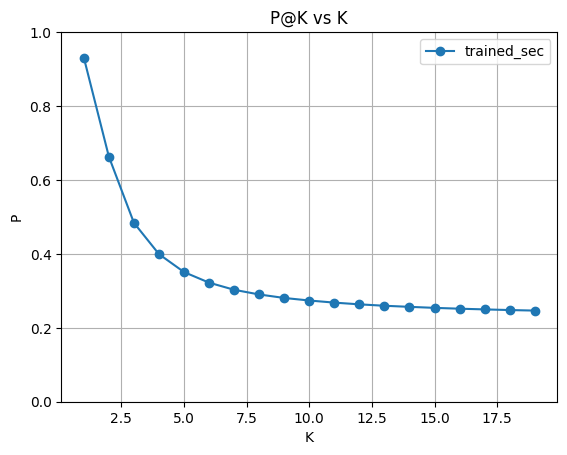

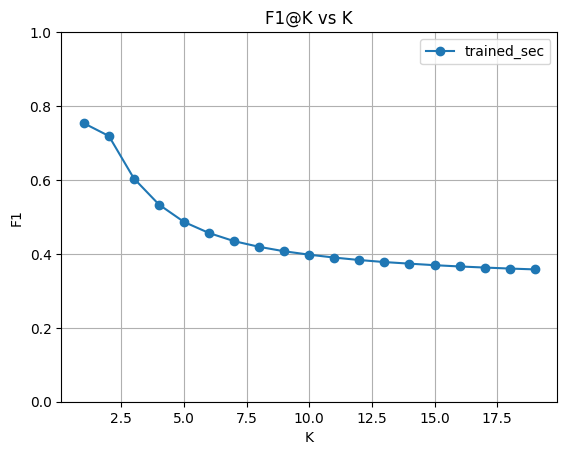

trained_sec nDCG@10: 0.9337
trained_sec {'lat_ms_mean': 13.640442273568128, 'lat_ms_p50': 12.467315500543918, 'lat_ms_p95': 20.88553735011373}


In [ ]:
results_ft_sec = evaluate(call_rerank_sectionwise, dataset=test_data)
plot_eval({ "trained_sec": results_ft_sec })

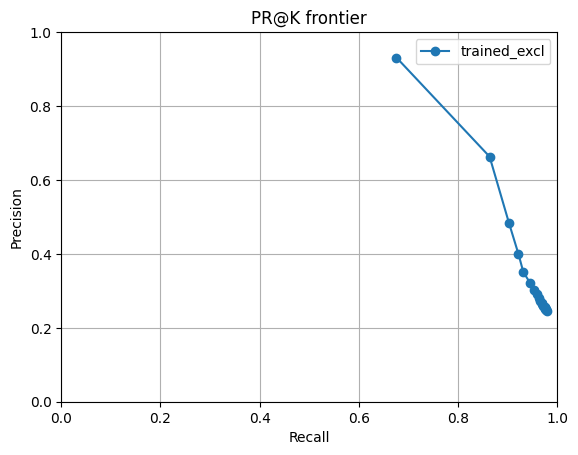

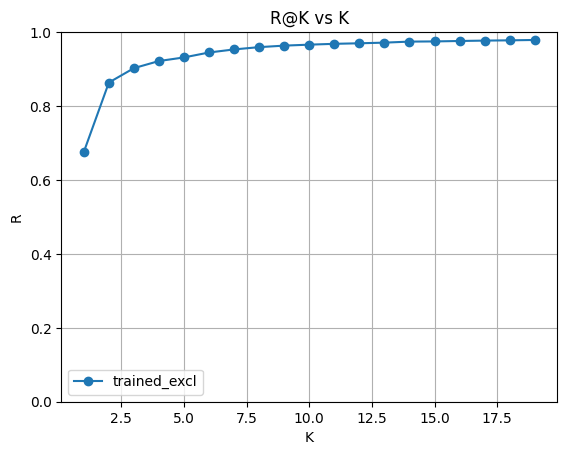

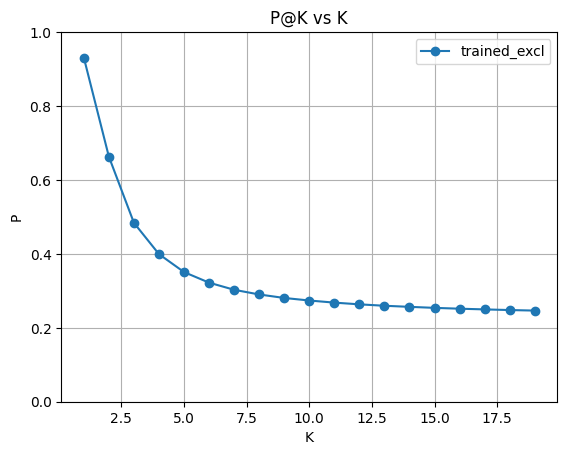

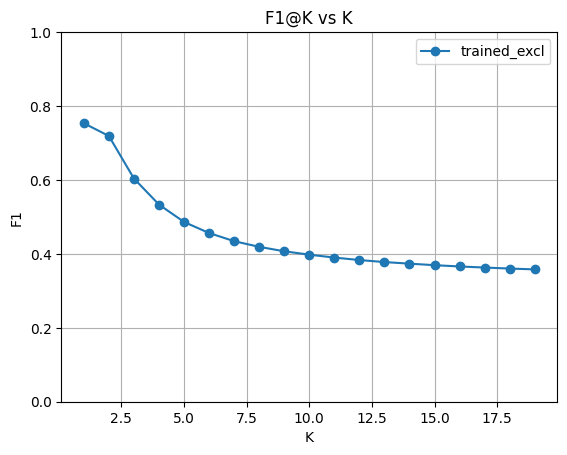

trained_excl nDCG@10: 0.9337
trained_excl {'lat_ms_mean': 13.640442273568128, 'lat_ms_p50': 12.467315500543918, 'lat_ms_p95': 20.88553735011373}


In [ ]:
EXCL_RUN = 'y5t635ks'

excl_reranker_model = CrossEncoder(f"./reranker-sweep/{EXCL_RUN}/checkpoint-2600")

def call_excl_rerank(example):
    input_dict, question, *_ = example
    return trained_rerank(excl_reranker_model, question, input_dict, top_k=20)

results_excl = evaluate(call_excl_rerank, dataset=test_data)
plot_eval({ "trained_excl": results_ft_sec })

### Conclusion

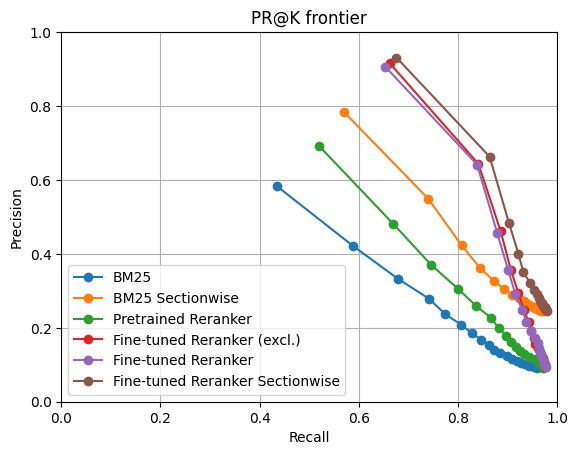

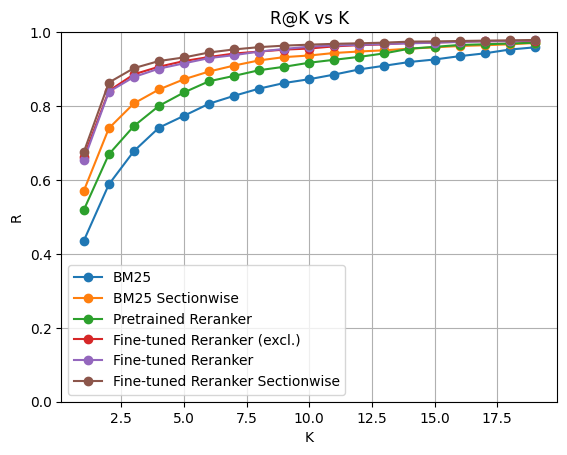

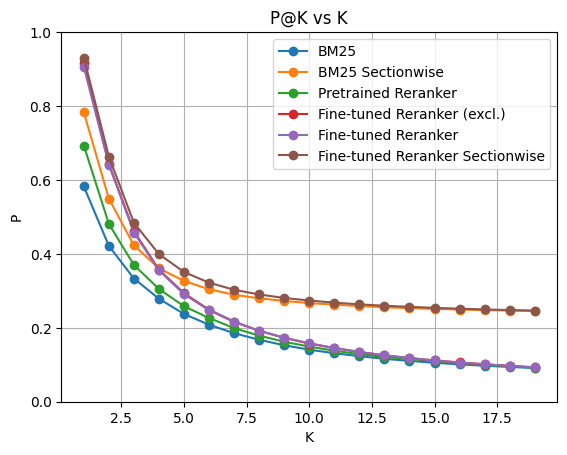

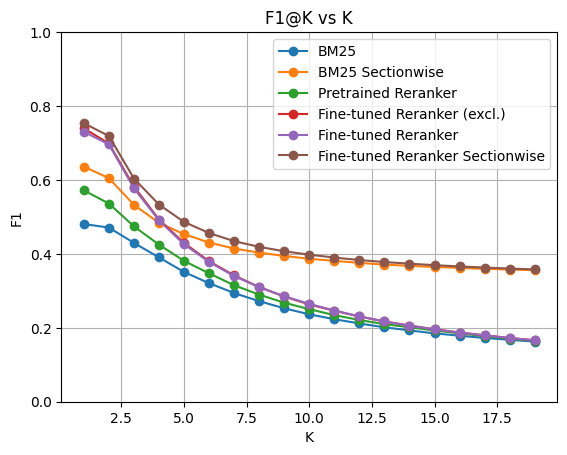

BM25 nDCG@10: 0.7182
BM25 Sectionwise nDCG@10: 0.8438
Pretrained Reranker nDCG@10: 0.7929
Fine-tuned Reranker (excl.) nDCG@10: 0.9180
Fine-tuned Reranker nDCG@10: 0.9148
Fine-tuned Reranker Sectionwise nDCG@10: 0.9337
BM25 {'lat_ms_mean': 0.7584140200960846, 'lat_ms_p50': 0.7297815009223996, 'lat_ms_p95': 1.1665004496535403}
BM25 Sectionwise {'lat_ms_mean': 0.7251115603028322, 'lat_ms_p50': 0.7192655002654647, 'lat_ms_p95': 1.044299799195869}
Pretrained Reranker {'lat_ms_mean': 14.916633403831806, 'lat_ms_p50': 13.30597150081303, 'lat_ms_p95': 24.782243651225137}
Fine-tuned Reranker (excl.) {'lat_ms_mean': 13.871719964124797, 'lat_ms_p50': 12.612357500074722, 'lat_ms_p95': 21.699783299573017}
Fine-tuned Reranker {'lat_ms_mean': 14.156886531490292, 'lat_ms_p50': 12.923299999783922, 'lat_ms_p95': 21.945291749852906}
Fine-tuned Reranker Sectionwise {'lat_ms_mean': 13.640442273568128, 'lat_ms_p50': 12.467315500543918, 'lat_ms_p95': 20.88553735011373}


In [ ]:
all_results = {
    "BM25": bm25_results,
    "BM25 Sectionwise": bm25_sectionwise_results,
    "Pretrained Reranker": results_pretrained,
    "Fine-tuned Reranker (excl.)": results_excl,
    "Fine-tuned Reranker": results_ft,
    "Fine-tuned Reranker Sectionwise": results_ft_sec,
}

plot_eval(all_results)
